# Time Travel
## Review
We discussed motivations for `human-in-the-loop`.
1. `Approval` - We can interrupt our agent, surface state to a user, and allow the user to accept an action.
2. `Debugging` - We can rewind the graph to reproduce or avoid issues.
3. `Editing` - You can modify the state.

We showed how breakpoints can stop the graph (`streaming_interruption.ipynb`) at specific nodes or allow the graph to dynamically interrupt itself (`dynamic_breakpoints.ipynb`).

Then we showed how to proceed with human approval or directly edit the graph state with human feedback (`edit_state_human_feedback.ipynb`).

## Goals
Now, let's show how LangGraph supports debugging by reviewing, re-playing, and even forking from past states.

We call this time travel.

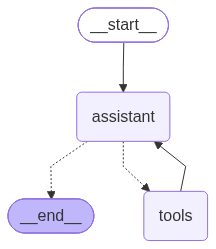

In [7]:
# Import libraries
import os, getpass
from dotenv import load_dotenv
from IPython.display import Image, display

from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, RemoveMessage

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

# Set the Chat Model
llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    """
    return a * b

def add(a: int, b: int) -> int:
    """
    Adds a and b.
    """
    return a + b

def divide(a: int, b: int) -> float:
    """
    Divide a by b.
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

# System Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [8]:
# Initial Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_00_KhqUbNWq1CpNRfiQLKml9304)
 Call ID: call_00_KhqUbNWq1CpNRfiQLKml9304
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

2 multiplied by 3 is **6**.


## Browsing History
We can use `get_state` to look at the current state of our graph, given the `thread_id`.

We can also browse the state history of our agent. `get_state_history` let's get the state at all prior steps.

In [9]:
graph.get_state({"configurable": {"thread_id": "1"}})
all_states = [s for s in graph.get_state_history(thread)]

print(len(all_states))
print(all_states[-2])

5
StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='d3427a88-c174-4416-b507-c34254981e79')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183df0-f541-6ae0-8000-8bc699b6843d'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-20T02:02:28.331147+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183df0-f531-647e-bfff-412eb96fb853'}}, tasks=(PregelTask(id='14cb0e2b-958b-a406-9731-95633215bead', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 416, 'total_tokens': 495, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 19, 'rejec

## Replaying
We can re-run our agent from any of the prior steps. Let's look back at the step that received human input.

Look at the state and the next node to call.

In [10]:
to_replay = all_states[-2]
print(to_replay)

print(to_replay.values)
print(to_replay.next)
print(to_replay.config)

for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event["messages"][-1].pretty_print()

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='d3427a88-c174-4416-b507-c34254981e79')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183df0-f541-6ae0-8000-8bc699b6843d'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-20T02:02:28.331147+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183df0-f531-647e-bfff-412eb96fb853'}}, tasks=(PregelTask(id='14cb0e2b-958b-a406-9731-95633215bead', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 416, 'total_tokens': 495, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 19, 'rejecte

## Forking
What if we want to run from that same step, but with a different input. This is forking.

Let's modify the state at this checkpoint. We can just run `update_state` with the `checkpoint_id` supplied.
Remember how our reducer on `messages` works:
- It will append, unless we supply a message ID.
- We supply the message ID to overwrite the message, rather than appending to state.

In [12]:
to_fork = all_states[-2]
fork_config = graph.update_state(
    to_fork.config,
    {"messages": [HumanMessage(content="Multiply 5 and 3",
                                id=to_fork.values["messages"][0].id)]},
)
print(fork_config)
all_states = [state for state in graph.get_state_history(thread)]
print(all_states[0].values["messages"])
print(graph.get_state({"configurable": {"thread_id": "1"}}))

for event in graph.stream(None, fork_config, stream_mode="values"):
    event["messages"][-1].pretty_print()

{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183df1-a57d-6436-8001-0153a9544560'}}
[HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='d3427a88-c174-4416-b507-c34254981e79')]
StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='d3427a88-c174-4416-b507-c34254981e79')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183df1-a57d-6436-8001-0153a9544560'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-20T02:02:46.810498+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183df0-f541-6ae0-8000-8bc699b6843d'}}, tasks=(PregelTask(id='328039c5-7611-a8c3-4f08-fac4905bea2d', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())
=========================